In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("/kaggle/input/datasets/andikanajmi/chocholate-sales/chocolate_sales_2025_dataset.csv")

df.head()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.00,194,970.00
1,2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12
2,3,2025-02-17,Toblerone,Dark Chocolate,Australia,Supermarket,Digital Wallet,7.42,134,994.28
3,4,2025-11-29,Ferrero,Truffles,Italy,Convenience Store,Cash,18.28,112,2047.36
4,5,2025-03-23,Cadbury,Milk Chocolate,France,Convenience Store,Cash,18.21,92,1675.32


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB


In [5]:
df.describe()

,Sale_ID,Price_USD,Units_Sold,Revenue_USD
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,13.779860,104.938000,1433.391140
std,144.481833,6.484013,56.263998,1065.679386
min,1.000000,2.520000,5.000000,20.480000
25%,125.750000,8.592500,56.750000,562.545000
50%,250.500000,13.480000,108.500000,1197.225000
75%,375.250000,19.445000,150.250000,2072.812500
max,500.000000,25.000000,200.000000,4809.260000


## Data Processing

Pada tahap ini dilakukan beberapa preprocessing data seperti:
- Mengecek missing values
- Mengubah format tanggal
- Mengubah data kategorikal menjadi numerik menggunakan Label Encoding

In [6]:
df.isnull().sum()

Sale_ID           0
Date              0
Brand             0
Product_Type      0
Country           0
Sales_Channel     0
Payment_Method    0
Price_USD         0
Units_Sold        0
Revenue_USD       0
dtype: int64

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month

In [8]:
le = LabelEncoder()

categorical_cols = ['Brand','Product_Type','Country','Sales_Channel','Payment_Method']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

EDA

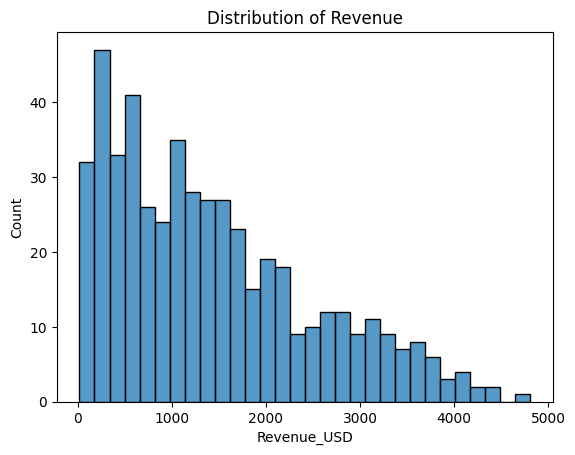

In [10]:
plt.figure()
sns.histplot(df['Revenue_USD'], bins=30)
plt.title("Distribution of Revenue")
plt.show()

### Distribution of Revenue

Histogram ini menunjukkan distribusi nilai **Revenue_USD** pada dataset penjualan cokelat.

Berdasarkan grafik, sebagian besar transaksi berada pada rentang revenue **500 hingga 2000 USD**. Hal ini menunjukkan bahwa mayoritas penjualan menghasilkan pendapatan pada tingkat menengah.

Distribusi revenue terlihat **right-skewed (miring ke kanan)**, dimana terdapat beberapa transaksi dengan nilai revenue yang sangat tinggi hingga mendekati **5000 USD**, namun jumlahnya relatif lebih sedikit.

Hal ini mengindikasikan bahwa:
- Sebagian besar transaksi merupakan pembelian dalam jumlah kecil hingga menengah.
- Hanya sebagian kecil transaksi yang menghasilkan revenue sangat tinggi.

Insight bisnis yang dapat diperoleh adalah bahwa perusahaan memiliki **beberapa transaksi bernilai tinggi (high-value sales)** yang kemungkinan berasal dari pembelian dalam jumlah besar atau produk dengan harga lebih tinggi.

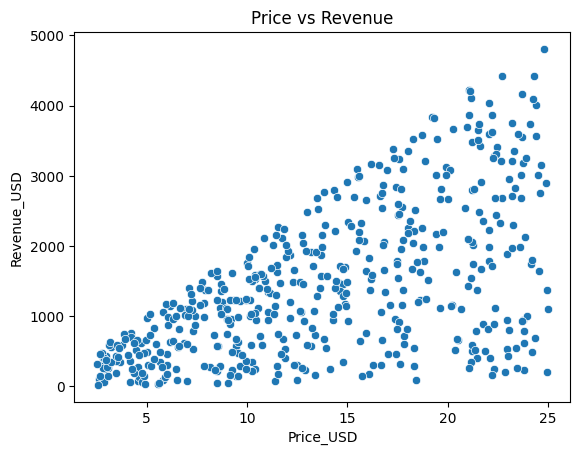

In [11]:
plt.figure()
sns.scatterplot(x='Price_USD', y='Revenue_USD', data=df)
plt.title("Price vs Revenue")
plt.show()

### Price vs Revenue

Scatter plot ini menunjukkan hubungan antara **Price_USD (harga produk)** dan **Revenue_USD (pendapatan penjualan)**.

Dari visualisasi dapat terlihat adanya **korelasi positif** antara harga produk dan revenue. Hal ini menunjukkan bahwa ketika harga produk meningkat, nilai revenue yang dihasilkan juga cenderung meningkat.

Namun, terdapat variasi yang cukup besar pada data, yang menunjukkan bahwa revenue tidak hanya dipengaruhi oleh harga produk saja, tetapi juga oleh faktor lain seperti **jumlah unit yang terjual (Units_Sold)**.

Beberapa titik dengan harga tinggi menghasilkan revenue yang sangat besar, yang kemungkinan menunjukkan transaksi dengan kombinasi **harga tinggi dan jumlah unit yang besar**.

Insight bisnis dari grafik ini adalah:
- Produk dengan harga lebih tinggi berpotensi menghasilkan revenue lebih besar.
- Namun strategi penjualan tetap perlu mempertimbangkan volume penjualan untuk memaksimalkan pendapatan.

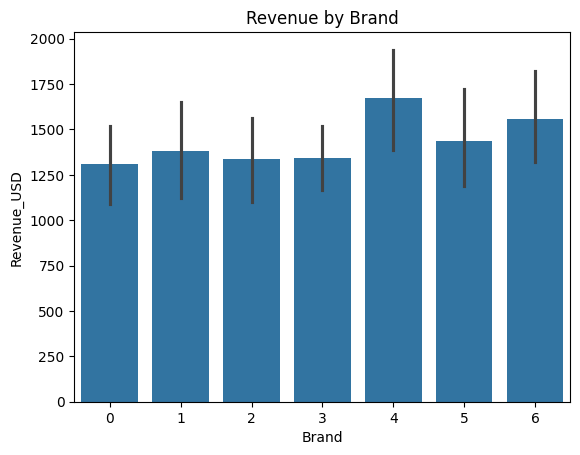

In [12]:
plt.figure()
sns.barplot(x='Brand', y='Revenue_USD', data=df)
plt.title("Revenue by Brand")
plt.show()

### Revenue by Brand

Grafik ini menunjukkan rata-rata **Revenue_USD** yang dihasilkan oleh setiap brand produk cokelat.

Dari visualisasi terlihat bahwa beberapa brand menghasilkan revenue yang lebih tinggi dibandingkan brand lainnya. Salah satu brand menunjukkan nilai revenue rata-rata paling tinggi, yang mengindikasikan bahwa brand tersebut memiliki performa penjualan yang lebih baik.

Perbedaan revenue antar brand dapat disebabkan oleh beberapa faktor, seperti:
- Popularitas brand
- Harga produk
- Jenis produk yang dijual
- Strategi pemasaran

Insight bisnis yang dapat diperoleh dari analisis ini adalah bahwa brand dengan revenue tinggi dapat dijadikan sebagai **produk unggulan (flagship products)** yang dapat diprioritaskan dalam strategi pemasaran dan distribusi.

In [13]:
X = df.drop(['Revenue_USD','Sale_ID','Date'], axis=1)
y = df['Revenue_USD']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Machine Learning Model

Pada tahap ini dilakukan training beberapa algoritma regression untuk memprediksi nilai revenue penjualan.

Model yang digunakan:
- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

Hyperparameter tuning dilakukan menggunakan GridSearchCV untuk mencari kombinasi parameter terbaik.

In [15]:
models = {
    
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },
    
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {
            "n_estimators":[100,200],
            "max_depth":[5,10,20],
            "min_samples_split":[2,5]
        }
    },
    
    "XGBoost": {
        "model": XGBRegressor(),
        "params":{
            "n_estimators":[100,200],
            "learning_rate":[0.01,0.1],
            "max_depth":[3,6,10]
        }
    }
}

In [16]:
results = []

for model_name, mp in models.items():
    
    print("Training", model_name)
    
    grid = GridSearchCV(
        mp["model"],
        mp["params"],
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    
    grid.fit(X_train,y_train)
    
    best_model = grid.best_estimator_
    
    y_pred = best_model.predict(X_test)
    
    r2 = r2_score(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    
    results.append({
        "Model":model_name,
        "Best Params":grid.best_params_,
        "R2 Score":r2,
        "RMSE":rmse
    })

Training LinearRegression
Training RandomForest
Training XGBoost


In [17]:
results_df = pd.DataFrame(results)

results_df

,Model,Best Params,R2 Score,RMSE
0,LinearRegression,{},0.868085,404.055985
1,RandomForest,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.992092,98.927796
2,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.996390,66.844281


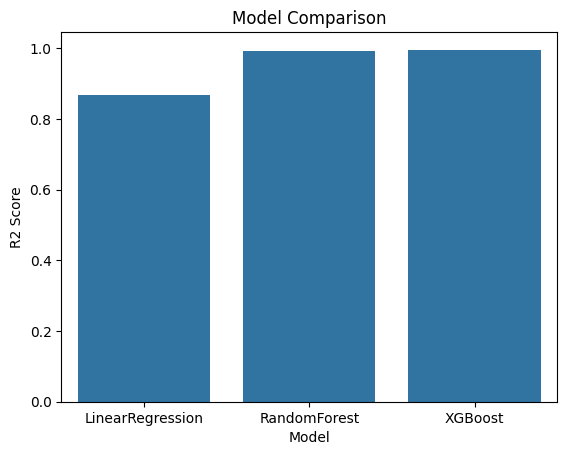

(None,)

In [18]:
plt.figure()

sns.barplot(
    x="Model",
    y="R2 Score",
    data=results_df
)

plt.title("Model Comparison")
plt.show(),

Hasil modelling regression yang paling mendekati akurat R2 ke 100,dan RMSE ke 0 ialah model XGboost

In [19]:
best_model = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

best_model

,Model,Best Params,R2 Score,RMSE
2,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.996390,66.844281
1,RandomForest,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.992092,98.927796
0,LinearRegression,{},0.868085,404.055985


## Sales Prediction Analysis (Regression)

Pada tahap ini dilakukan analisis **Sales Prediction** menggunakan beberapa algoritma machine learning untuk memprediksi nilai **Revenue (Revenue_USD)** berdasarkan berbagai fitur dalam dataset penjualan cokelat.

Beberapa algoritma regression yang digunakan dalam eksperimen ini adalah:

- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

Untuk meningkatkan performa model, dilakukan **hyperparameter tuning menggunakan GridSearchCV**. Proses ini bertujuan untuk menemukan kombinasi parameter terbaik dari setiap model sehingga menghasilkan performa prediksi yang optimal.

Evaluasi model dilakukan menggunakan dua metrik utama, yaitu:

- **R² Score (Coefficient of Determination)**  
  Mengukur seberapa baik model mampu menjelaskan variasi data. Nilai yang mendekati **1** menunjukkan performa model yang sangat baik.

- **RMSE (Root Mean Squared Error)**  
  Mengukur rata-rata kesalahan prediksi model. Semakin kecil nilai RMSE, semakin akurat model dalam melakukan prediksi.

---

## Hasil Perbandingan Model

Berdasarkan hasil evaluasi model, diperoleh performa sebagai berikut:

| Model | R² Score | RMSE |
|------|------|------|
| XGBoost | 0.996 | 66.84 |
| Random Forest | 0.992 | 98.93 |
| Linear Regression | 0.868 | 404.05 |

Dari hasil tersebut dapat terlihat bahwa **XGBoost Regressor menghasilkan performa terbaik** dengan nilai **R² Score tertinggi sebesar 0.996** dan **RMSE terendah sebesar 66.84**.

Random Forest juga menunjukkan performa yang sangat baik dengan R² Score sebesar **0.992**, namun masih sedikit di bawah performa XGBoost.

Sementara itu, Linear Regression memiliki performa yang lebih rendah dibandingkan model berbasis ensemble karena algoritma ini hanya mampu menangkap hubungan linear antar variabel, sedangkan data penjualan kemungkinan memiliki hubungan yang lebih kompleks dan non-linear.

---

## Interpretasi Hasil

Hasil ini menunjukkan bahwa algoritma berbasis **ensemble learning**, seperti Random Forest dan XGBoost, lebih efektif dalam memodelkan pola pada dataset penjualan.

Hal ini disebabkan karena:

- Model ensemble mampu menangkap hubungan **non-linear antar variabel**
- Model mampu menangani **interaksi kompleks antar fitur**
- Model lebih tahan terhadap **noise dalam data**

Dengan performa yang sangat tinggi (R² ≈ 0.996), model XGBoost mampu menjelaskan hampir seluruh variasi dalam data revenue.

---

## Kesimpulan

Berdasarkan hasil eksperimen regression yang dilakukan, dapat disimpulkan bahwa:

1. **XGBoost Regressor merupakan model terbaik** untuk memprediksi revenue pada dataset ini.
2. Model XGBoost menghasilkan **R² Score sebesar 0.996**, yang menunjukkan kemampuan prediksi yang sangat tinggi.
3. Nilai **RMSE yang rendah (66.84)** menunjukkan bahwa kesalahan prediksi model relatif kecil.
4. Model berbasis ensemble seperti Random Forest dan XGBoost terbukti lebih efektif dibandingkan model linear dalam memprediksi penjualan.

Dengan menggunakan model ini, perusahaan dapat melakukan **prediksi penjualan secara lebih akurat**, sehingga dapat membantu dalam:

- Perencanaan stok produk
- Strategi pemasaran
- Pengambilan keputusan bisnis berbasis data

## **Customer Segment Clustering**

In [20]:
clustering_data = df[['Price_USD','Units_Sold','Revenue_USD']]

In [21]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(clustering_data)

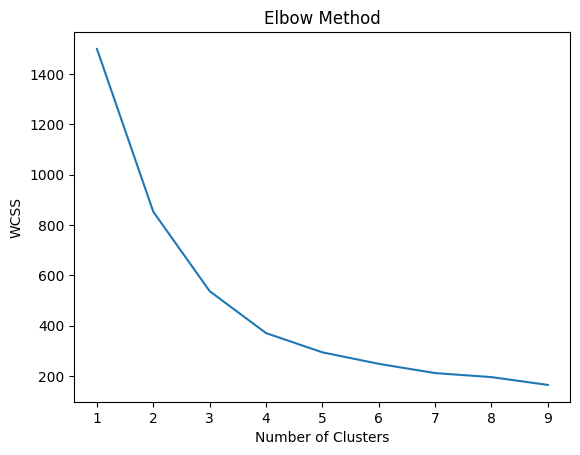

In [22]:
wcss = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

Setelah 4, kurva mulai landai
Elbow terlihat di sekitar k = 4

In [23]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_data)

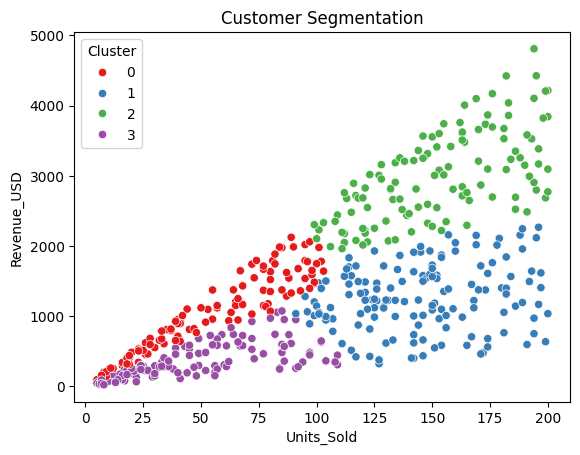

In [24]:
plt.figure()

sns.scatterplot(
    x=df['Units_Sold'],
    y=df['Revenue_USD'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segmentation")
plt.show()

## Customer Segmentation Analysis (K-Means)

Berdasarkan hasil analisis menggunakan algoritma **K-Means Clustering**, dataset penjualan cokelat berhasil dikelompokkan menjadi **4 cluster pelanggan**. Penentuan jumlah cluster dilakukan menggunakan **Elbow Method**, dimana titik elbow terlihat pada **k = 4**, sehingga dipilih empat cluster sebagai jumlah optimal untuk segmentasi.

Visualisasi clustering menunjukkan hubungan antara **Units Sold (jumlah unit terjual)** dan **Revenue (pendapatan)**, dimana masing-masing cluster memiliki karakteristik perilaku pembelian yang berbeda.

---

## Interpretasi Setiap Cluster

### Cluster 0 – Medium Buyers

Cluster ini merepresentasikan pelanggan dengan tingkat pembelian **menengah**.  
Mereka membeli jumlah unit yang cukup banyak dengan revenue yang juga berada pada tingkat sedang.

**Karakteristik:**
- Units Sold: sekitar **50 – 100**
- Revenue: sekitar **800 – 2000 USD**
- Kontribusi penjualan **cukup stabil**

**Insight Bisnis:**
Pelanggan dalam cluster ini memiliki potensi untuk ditingkatkan menjadi **high-value customers** melalui strategi seperti promosi atau bundling produk.

---

### Cluster 1 – Bulk Buyers

Cluster ini terdiri dari pelanggan dengan **jumlah pembelian unit yang sangat tinggi**, namun revenue tidak selalu meningkat secara proporsional.

**Karakteristik:**
- Units Sold: sekitar **100 – 200**
- Revenue: sekitar **600 – 2200 USD**

**Insight Bisnis:**
Pelanggan dalam cluster ini kemungkinan membeli dalam **jumlah besar dengan harga diskon**.

Strategi yang dapat dilakukan:
- Optimasi margin penjualan
- Cross-selling produk premium
- Penawaran paket produk dengan nilai lebih tinggi

---

### Cluster 2 – High Value Customers

Cluster ini merupakan **segmen pelanggan paling bernilai**.

**Karakteristik:**
- Units Sold: sekitar **100 – 200**
- Revenue: sekitar **2000 – 4800 USD**

**Insight Bisnis:**
Pelanggan pada cluster ini memberikan **kontribusi revenue terbesar** bagi perusahaan.

Strategi yang dapat dilakukan:
- Loyalty program
- Premium offers
- Exclusive promotions

Tujuan dari strategi ini adalah **mempertahankan pelanggan bernilai tinggi**.

---

### Cluster 3 – Low Value Customers

Cluster ini merepresentasikan pelanggan dengan **jumlah pembelian kecil dan revenue rendah**.

**Karakteristik:**
- Units Sold: sekitar **0 – 80**
- Revenue: sekitar **0 – 1000 USD**

**Insight Bisnis:**
Segmen ini berpotensi menjadi **target promosi awal** untuk meningkatkan pembelian.

Strategi yang dapat dilakukan:
- Diskon produk
- Paket bundling
- Promosi produk entry-level

---

## Kesimpulan

Berdasarkan hasil segmentasi menggunakan **K-Means Clustering**, pelanggan dapat dibagi menjadi empat kelompok utama berdasarkan pola pembelian dan kontribusi revenue.

Segmentasi ini memberikan wawasan penting bagi perusahaan untuk:

- Mengidentifikasi pelanggan dengan **nilai tinggi**
- Menentukan strategi pemasaran yang **lebih terarah**
- Meningkatkan potensi revenue dari pelanggan dengan pembelian menengah atau rendah

Dengan memanfaatkan hasil clustering ini, perusahaan dapat menerapkan **strategi pemasaran berbasis data (data-driven marketing)** untuk meningkatkan penjualan dan mempertahankan pelanggan bernilai tinggi.